In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [19]:
df = pd.read_csv("/placement_predict_50k Dataset.csv")
FEATURES = [
    "CGPA", "AttendancePercent", "Internships", "Projects",
    "Workshops", "Certifications", "Publications",
    "AptitudeTestScore", "SoftSkillsRating",
    "CodingTestScore", "MockInterviewScore", "ExtraCurricular"
]

TARGET = "Salary Package"

data = df[FEATURES + [TARGET]].copy()
data[FEATURES] = data[FEATURES].fillna(data[FEATURES].median())

In [20]:
X = data[FEATURES].values
y = data[TARGET].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 12)
y shape: (50000, 1)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 12)
Testing data: (10000, 12)


In [22]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [23]:
X_train_b = np.hstack([np.ones((X_train_s.shape[0], 1)), X_train_s])
X_test_b = np.hstack([np.ones((X_test_s.shape[0], 1)), X_test_s])

print("Bias column added")

Bias column added


In [24]:
def compute_mse(X, y, theta):
    predictions = X @ theta
    errors = predictions - y
    return np.mean(errors ** 2)

In [25]:
def batch_gradient_descent(X, y, lr=0.05, n_epochs=500):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(n_epochs):
        predictions = X @ theta
        errors = predictions - y
        gradient = (2 / m) * (X.T @ errors)
        theta -= lr * gradient
        loss_history.append(compute_mse(X, y, theta))

    return theta, loss_history

In [26]:
theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b, y_train
)

rmse_gd = np.sqrt(compute_mse(X_test_b, y_test, theta_gd))

print(f"Batch GD Test RMSE: {rmse_gd:.4f}")

Batch GD Test RMSE: 4.4105


In [27]:
model = LinearRegression()

model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

rmse_sklearn = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"Sklearn Test RMSE: {rmse_sklearn:.4f}")

Sklearn Test RMSE: 4.4105


In [28]:
def mini_batch_gradient_descent(X, y, lr=0.05, n_epochs=500, batch_size=256):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    rng = np.random.default_rng(42)

    for epoch in range(n_epochs):
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, m, batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            predictions = X_batch @ theta
            errors = predictions - y_batch

            gradient = (2 / len(X_batch)) * (X_batch.T @ errors)
            theta -= lr * gradient

        loss_history.append(compute_mse(X, y, theta))

    return theta, loss_history

In [29]:
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b, y_train
)

rmse_mb = np.sqrt(
    compute_mse(X_test_b, y_test, theta_mb)
)

print(f"Mini-Batch GD Test RMSE: {rmse_mb:.4f}")

Mini-Batch GD Test RMSE: 4.4190


In [30]:
print("=== RMSE Comparison ===")

print(f"Batch GD       : {rmse_gd:.4f}")
print(f"Mini-Batch GD  : {rmse_mb:.4f}")
print(f"Sklearn Linear : {rmse_sklearn:.4f}")

=== RMSE Comparison ===
Batch GD       : 4.4105
Mini-Batch GD  : 4.4190
Sklearn Linear : 4.4105


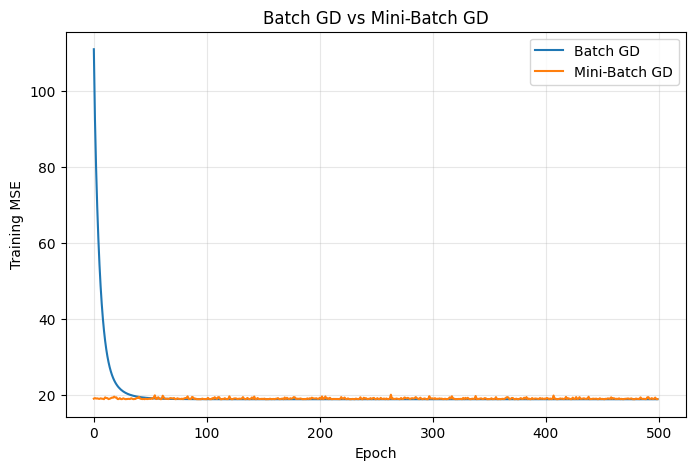

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history_gd, label="Batch GD")
plt.plot(loss_history_mb, label="Mini-Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Batch GD vs Mini-Batch GD")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
print("=== Final Result ===")
print(f"Batch GD RMSE      : {rmse_gd:.4f}")
print(f"Mini-Batch GD RMSE : {rmse_mb:.4f}")
print(f"Sklearn RMSE       : {rmse_sklearn:.4f}")

=== Final Result ===
Batch GD RMSE      : 4.4105
Mini-Batch GD RMSE : 4.4190
Sklearn RMSE       : 4.4105
